# 05. Model Metadata와 Run Registry: 데이터 전처리 lineage 잠금

> 작성일: 2026-07-11 KST  
> 범위: 공식 데이터 파악, baseline 전처리 profile, 모델 metadata sidecar, local validation과 submission을 잇는 run registry  
> 안전 원칙: 이 노트북은 공식 원본을 읽기만 하며, 실제 모델 파일·제출 CSV·`outputs/` 산출물을 만들지 않는다.

이번 P0의 핵심은 모델 파일을 하나 더 저장하는 일이 아니다. **어떤 데이터가 어떤 전처리를 거쳐 어떤 feature 순서로 모델에 들어갔는지**를 모델 bytes와 함께 잠그고, local validation과 제출 hash가 같은 `run_id`를 공유하게 만드는 일이다.

## 연구 질문

1. 공식 label·LDAPS·GFS의 구조와 결측 원인이 metadata에 충분히 남는가?
2. 격자 평균, lead hour, calendar, median imputation, target별 mask라는 현재 전처리 계약을 hash로 고정할 수 있는가?
3. 모델 bytes 변조나 feature 순서 drift를 inference 전에 탐지할 수 있는가?
4. local validation 결과와 submission ledger를 한 run registry 행으로 연결할 수 있는가?


## 벤치마킹 융합표

기존 BARAM 노트북과 3조 분석 노트북을 단순히 인용하지 않고, 이번 노트북의 장 구조와 검증 게이트로 옮긴다.

| 벤치마크 | 유지할 강점 | 이번 P0 적용 |
|---|---|---|
| `00_official_data_audit` | 원본 hash, source별 결측 원인, cutoff | metadata의 `input_files`, label/weather profile |
| `01_metric_reproduction` | valid mask와 metric 책임 분리 | validation 구간·3개 점수를 registry 필드로 고정 |
| `02_official_baseline_reproduction` | 공식 feature와 2024 holdout | 같은 baseline 전처리와 time holdout을 메모리에서 재현 |
| `03_reproducible_submission_ledger` | config/seed/commit/data/submission hash | config hash를 model metadata와 run registry까지 확장 |
| `04_submission_validator_and_cli` | 저장 전 validator와 canonical bytes | 검증된 submission hash만 기존 run 행에 연결 |
| 공식 baseline | mean aggregation, calendar, target별 모델 | 현재 P0 전처리 계약의 출발점으로 유지 |
| 3조 `10/11/20/30` | 연구 질문, 전후 비교, Decision Box, 증거 사다리 | 데이터 파악부터 결론까지 단계별 게이트 배치 |
| EDA 강의 5단계 | 데이터 파악→전처리→속성 탐색→시각화→해석 | 이 노트북의 1~5장으로 그대로 사용 |

**벤치마킹 원칙**: 노트북에는 과정과 증거를 남기고, 재사용 로직의 정본은 `src/baram/`에 둔다. 모델·CSV 저장은 명시적 CLI에서만 허용한다.


## 전문가 방법론: 5단계와 증거 사다리

| 단계 | 질문 | 실행 증거 | 다음 단계 게이트 |
|---:|---|---|---|
| 1. 데이터 파악 | source별 행·기간·grid·lead·결측은 무엇인가? | 공식 CSV inventory와 bytes hash | 원인별 결측 구분 |
| 2. 전처리/가공 | raw grid가 어떤 규칙으로 feature가 되는가? | feature schema, 결측 전후, preprocessing hash | train/inference 동일 계약 |
| 3. 속성 탐색 | target 가용성과 feature family는 어떤 구조인가? | target별 mask, feature family 표 | Group 3과 source별 차이 노출 |
| 4. 시각화 | 압축·결측·학습 가용성을 한눈에 볼 수 있는가? | raw→forecast 압축, target 가용성 차트 | 해석 없는 그래프 금지 |
| 5. 해석/등록 | 어떤 artifact를 채택하고 무엇을 금지하는가? | model/metadata/registry hash chain | 변조·drift 실패 시 저장/추론 중단 |

3조의 증거 사다리처럼 앞 단계가 무너지면 뒤 단계도 승격하지 않는다. 원본 fingerprint가 없으면 preprocessing hash는 데이터 버전을 증명하지 못하고, feature schema가 다르면 같은 모델 파일이어도 동일 run으로 보지 않는다.


In [1]:
from pathlib import Path
import copy
import hashlib
import json
import subprocess
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd() if Path.cwd().name != "notebooks" else Path.cwd().parent
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
  sys.path.insert(0, str(SRC_DIR))

from baram.baseline import (
  build_training_features,
  predict_random_forest_baseline,
  train_random_forest_baseline,
)
from baram.metrics import TARGET_COLS, metric
from baram.registry import (
  build_model_artifact,
  build_run_registry_entry,
  build_training_data_profile,
  fingerprint_files,
  load_model_artifact_bytes,
)
from baram.reproducibility import BaselineRunConfig

DATA_DIR = PROJECT_ROOT / "data" / "raw" / "open"
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

{
  "project_root": str(PROJECT_ROOT),
  "data_dir_exists": DATA_DIR.exists(),
  "artifact_policy": "read-only data, in-memory model bytes, no outputs",
}

{'project_root': 'C:\\Users\\kik32\\workspace\\Dacon\\2026-BARAM-Wind-Power-Prediction-AI-Competition',
 'data_dir_exists': True,
 'artifact_policy': 'read-only data, in-memory model bytes, no outputs'}

## 1단계. 데이터 파악: metadata가 잠가야 할 원본 계약

모델 metadata의 출발점은 모델 파라미터가 아니라 입력 데이터다. 아래 셀은 학습에 직접 쓰는 세 파일의 bytes hash, 행 수, 기간, grid 수, lead 범위, 결측을 확인한다. 원본은 수정하지 않는다.

특히 결측을 하나의 숫자로만 보지 않는다.

- Group 3의 2022 label 결측은 구조적 미제공이므로 target별 학습 mask가 필요하다.
- weather 결측은 평가 시에도 재현 가능한 train median imputation으로 처리해야 한다.
- `data_available_kst_dtm`은 미래 정보 사용 여부를 판정하는 cutoff 기준이다.


In [2]:
input_paths = {
  "train_labels": DATA_DIR / "train" / "train_labels.csv",
  "ldaps_train": DATA_DIR / "train" / "ldaps_train.csv",
  "gfs_train": DATA_DIR / "train" / "gfs_train.csv",
}
missing_files = [name for name, path in input_paths.items() if not path.exists()]
assert not missing_files, f"공식 학습 파일 누락: {missing_files}"

input_fingerprints = fingerprint_files(input_paths)
train_labels = pd.read_csv(input_paths["train_labels"], encoding="utf-8-sig")
ldaps_train = pd.read_csv(input_paths["ldaps_train"], encoding="utf-8-sig")
gfs_train = pd.read_csv(input_paths["gfs_train"], encoding="utf-8-sig")

inventory = pd.DataFrame(
  [
    {
      "source": name,
      "rows": len(frame),
      "columns": len(frame.columns),
      "missing_cells": int(frame.isna().sum().sum()),
      "bytes": input_fingerprints[name]["bytes"],
      "sha256_prefix": input_fingerprints[name]["sha256"][:12],
    }
    for name, frame in {
      "train_labels": train_labels,
      "ldaps_train": ldaps_train,
      "gfs_train": gfs_train,
    }.items()
  ]
)
display(inventory)


,source,rows,columns,missing_cells,bytes,sha256_prefix
0,train_labels,26304,4,8973,1138967,47bb64252195
1,ldaps_train,420864,35,0,129687357,61ae944e7ae1
2,gfs_train,236736,40,0,84315594,cd56b67d357e


### 관찰 → 해석 → 다음 판단

**관찰**: label은 시간당 한 행이고 LDAPS/GFS는 같은 forecast 시각을 여러 grid 행으로 반복한다. source별 파일 bytes와 SHA256은 동일한 파일명 아래 다른 데이터가 들어오는 상황을 막는 1차 증거다.

**해석**: 모델 pickle만 보관하면 어떤 원본 파일로 학습했는지 복구할 수 없다. MANIFEST hash 하나도 중요하지만, 실제 학습에 사용한 세 입력 파일의 개별 hash를 sidecar에 함께 남겨야 데이터 교체를 탐지할 수 있다.

**다음 판단**: 원본 inventory를 feature 생성 전 profile로 승격하고, 전처리 후 feature schema와 별도 hash로 연결한다.


## 2단계. 데이터 전처리/가공: raw grid에서 feature contract로

현재 baseline 전처리는 다음 순서다.

1. `data_available_kst_dtm <= forecast_kst_dtm` cutoff 검사
2. LDAPS/GFS를 source별 `forecast_kst_dtm` 단위 숫자형 평균으로 집계
3. source별 lead hour 추가
4. label 시간축에 weather를 left join
5. hour/month/dayofweek와 sin/cos calendar feature 추가
6. 학습 때만 median imputer fit
7. target별 non-null mask로 별도 모델 학습

여기서는 개선 피처를 섞지 않는다. P0의 목적은 현재 전처리를 **설명 가능한 계약과 hash**로 잠그는 것이다.


In [3]:
train_features = build_training_features(
  train_labels,
  ldaps_train,
  gfs_train,
)
data_profile = build_training_data_profile(
  train_labels=train_labels,
  ldaps_train=ldaps_train,
  gfs_train=gfs_train,
  train_features=train_features,
)

weather_profile = pd.DataFrame(data_profile["weather"]).T.reset_index(names="source")
feature_profile = pd.DataFrame(
  [
    {
      "rows": data_profile["feature_matrix"]["rows"],
      "columns": data_profile["feature_matrix"]["columns"],
      "missing_cells_before_imputation": data_profile["feature_matrix"]["missing_cells_before_imputation"],
      "rows_with_missing_before_imputation": data_profile["feature_matrix"]["rows_with_missing_before_imputation"],
      "feature_schema_sha256": data_profile["feature_matrix"]["feature_schema_sha256"],
    }
  ]
)
display(weather_profile[[
  "source", "rows", "forecast_rows", "grid_count_min", "grid_count_max",
  "lead_hour_min", "lead_hour_max", "missing_cells",
]])
display(feature_profile)


,source,rows,forecast_rows,grid_count_min,grid_count_max,lead_hour_min,lead_hour_max,missing_cells
0,ldaps,420864,26304,16,16,12.0,35.0,0
1,gfs,236736,26304,9,9,12.0,35.0,0


,rows,columns,missing_cells_before_imputation,rows_with_missing_before_imputation,feature_schema_sha256
0,26304,76,0,0,dbbdc27cfebc8db05be428afb075023ffa2f5086d9d1d0...


### 관찰 → 해석 → 다음 판단

**관찰**: raw weather 수십만 행은 forecast 시각당 한 행으로 압축되고, feature column order가 학습과 inference의 변환 순서를 결정한다. 결측은 imputer 적용 전 개수로 기록돼야 실제 가공 부담이 숨겨지지 않는다.

**해석**: `SimpleImputer` 객체가 pickle 안에 있더라도 “왜 median을 썼는가”, “어떤 column 순서에 fit했는가”는 사람이 복구하기 어렵다. 따라서 sidecar는 전처리 설명, feature 이름·dtype·순서, schema hash를 모두 가져야 한다.

**다음 판단**: 모델 저장 전에 bundle의 `feature_columns`와 data profile의 feature 순서가 완전히 같은지 검증한다. 하나라도 다르면 artifact 생성을 실패시킨다.


## Decision Box 1. 전처리 metadata의 최소 계약

| 항목 | 결정 | 이유 | 실패 시 처리 |
|---|---|---|---|
| 원본 fingerprint | MANIFEST + 실제 입력 파일별 SHA256 | 같은 파일명의 데이터 교체 탐지 | 모델 등록 금지 |
| weather profile | row/forecast/grid/lead/결측 기록 | 격자 누락과 cutoff drift 해석 | 모델 등록 금지 |
| aggregation | source별 mean과 lead를 명시 | 공식 baseline 재현 기준 | 다른 통계는 새 config/run |
| 결측 처리 | imputation 전 결측 수 + median 전략 기록 | 결측 원인을 숨기지 않음 | train/inference 전략 불일치 금지 |
| feature schema | column 이름·dtype·순서 SHA256 | 변환 순서가 모델 의미를 결정 | inference 중단 |
| target mask | target별 실제 학습 행 수 기록 | Group 3 구조적 결측 반영 | 공통 행 수로 위장 금지 |

**채택**: 전처리 코드는 pickle 내부 구현에만 맡기지 않고, 사람이 읽는 JSON sidecar와 hash로 외부화한다.


## 3단계. 속성 탐색: target 가용성과 feature family

전처리 결과를 단일 shape로만 보면 Group 3의 짧은 label 기간과 LDAPS/GFS 역할 차이가 사라진다. target별 non-null/missing/capacity 초과와 feature family 구성을 분리해 본다.


In [4]:
label_profile = data_profile["labels"]
target_profile = pd.DataFrame(
  [
    {
      "target": target,
      "non_null_rows": label_profile["target_non_null_rows"][target],
      "missing_rows": label_profile["target_missing_rows"][target],
      "capacity_exceedance_rows": label_profile["capacity_exceedance_rows"][target],
    }
    for target in TARGET_COLS
  ]
)

def feature_family(column):
  if column.startswith("ldaps_"):
    return "LDAPS"
  if column.startswith("gfs_"):
    return "GFS"
  return "Calendar"

feature_family_profile = (
  pd.Series([feature_family(column) for column in train_features.X.columns])
  .value_counts()
  .rename_axis("feature_family")
  .reset_index(name="feature_count")
)
display(target_profile)
display(feature_family_profile)


,target,non_null_rows,missing_rows,capacity_exceedance_rows
0,kpx_group_1,26200,104,0
1,kpx_group_2,26201,103,0
2,kpx_group_3,17538,8766,38


,feature_family,feature_count
0,GFS,36
1,LDAPS,31
2,Calendar,9


### 관찰 → 해석 → 다음 판단

**관찰**: Group 3은 Group 1/2보다 학습 가능한 행이 적고 일부 actual은 capacity를 넘는다. feature는 LDAPS와 GFS가 대부분을 차지하며 calendar는 작은 공통 축이다.

**해석**: 세 target을 같은 행 수로 기록하면 Group 3의 학습 조건을 왜곡한다. 또한 feature 개수만 기록하면 source별 역할과 전처리 변경을 추적하기 어렵다.

**다음 판단**: metadata에는 target별 `train_rows`를 모델 객체에서 직접 가져오고, registry에는 sidecar 전체를 복제하지 않고 `data_profile_sha256`, `preprocessing_sha256`, `feature_schema_sha256` 세 fingerprint만 인덱스로 둔다.


## 4단계. 시각화: raw→feature 압축과 학습 가용성

그래프는 장식이 아니라 전처리 계약이 실제 데이터에서 어떤 차이를 만드는지 확인하는 검증 도구다. 아래 두 패널은 source별 raw grid 압축률과 target별 label 가용성을 보여준다.


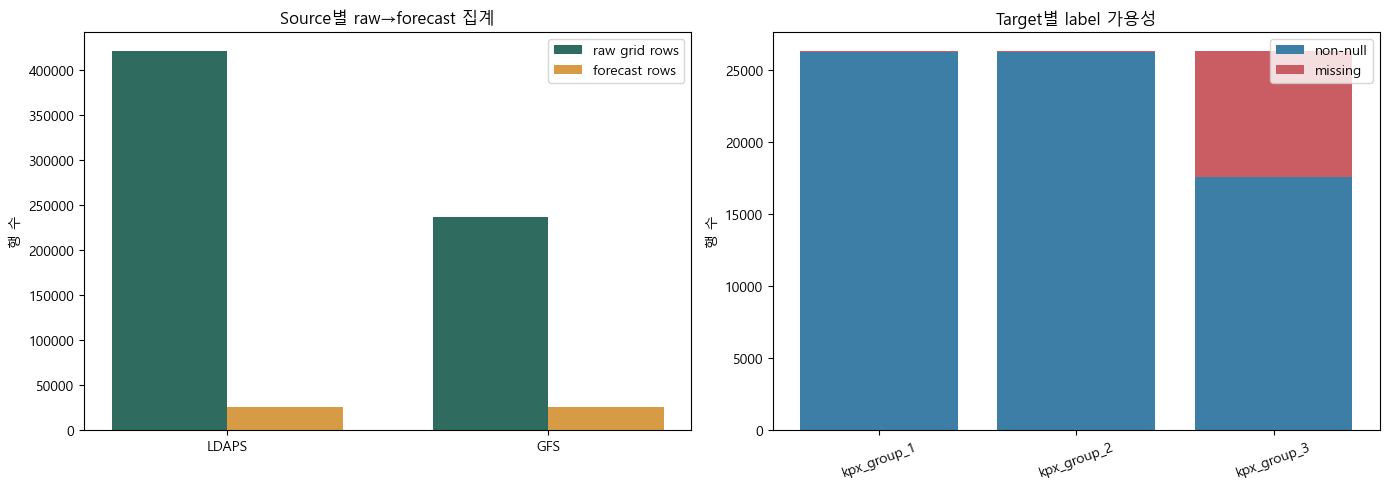

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

source_names = ["LDAPS", "GFS"]
raw_rows = [data_profile["weather"]["ldaps"]["rows"], data_profile["weather"]["gfs"]["rows"]]
forecast_rows = [
  data_profile["weather"]["ldaps"]["forecast_rows"],
  data_profile["weather"]["gfs"]["forecast_rows"],
]
x = np.arange(len(source_names))
width = 0.36
axes[0].bar(x - width / 2, raw_rows, width, label="raw grid rows", color="#2F6B5F")
axes[0].bar(x + width / 2, forecast_rows, width, label="forecast rows", color="#D89B45")
axes[0].set_xticks(x, source_names)
axes[0].set_title("Source별 raw→forecast 집계")
axes[0].set_ylabel("행 수")
axes[0].legend()

axes[1].bar(target_profile["target"], target_profile["non_null_rows"], label="non-null", color="#3D7EA6")
axes[1].bar(
  target_profile["target"],
  target_profile["missing_rows"],
  bottom=target_profile["non_null_rows"],
  label="missing",
  color="#C95D63",
)
axes[1].set_title("Target별 label 가용성")
axes[1].set_ylabel("행 수")
axes[1].tick_params(axis="x", rotation=20)
axes[1].legend()

plt.tight_layout()
plt.show()


### 관찰 → 해석 → 다음 판단

**관찰**: LDAPS 16개, GFS 9개 grid가 forecast 한 행으로 압축되면서 공간 정보가 크게 줄어든다. Group 3은 결측 블록 때문에 실제 학습 표본이 눈에 띄게 작다.

**해석**: 현재 mean aggregation은 빠르고 재현 가능하지만 공간 분산을 버린다. 이 사실은 P0 metadata에 “채택한 전처리”로 기록하되, 성능 개선으로 오해하지 않는다. 다음 feature 실험에서 std/min/max를 추가하면 preprocessing hash와 feature schema hash가 달라져 별도 run이 된다.

**강건성 경계**: 이번 P0는 전처리 lineage를 잠그는 작업이다. mean 대 std/min/max 성능 비교는 다음 feature-lab 작업으로 넘긴다.


## 5단계. 해석과 등록: model bytes → sidecar → run registry

2024 time holdout을 사용해 baseline smoke model을 메모리에서만 학습한다. 실제 모델 파일은 쓰지 않는다. local metric과 split 경계, input fingerprint, preprocessing profile을 model artifact metadata에 연결한 뒤 run registry 한 행을 메모리 DataFrame으로 확인한다.

RandomForest tree 수는 실행 비용을 줄이기 위한 notebook smoke 값이다. 이 점수는 제출 후보 성능이 아니라 registry 계약이 실제 공식 데이터에서 작동하는지 보여주는 실행 증거다.


In [6]:
forecast_year = pd.to_datetime(train_features.frame["forecast_kst_dtm"]).dt.year
train_mask = forecast_year < 2024
valid_mask = forecast_year == 2024

smoke_params = {
  "n_estimators": 8,
  "max_depth": 8,
  "min_samples_leaf": 8,
  "max_features": "sqrt",
  "n_jobs": 1,
}
config = BaselineRunConfig(
  experiment_id="rf_registry_2024_holdout_smoke",
  seed=42,
  model_params=smoke_params,
  notes="05 notebook in-memory registry contract smoke",
)
bundle = train_random_forest_baseline(
  train_features.X.loc[train_mask],
  train_features.frame.loc[train_mask],
  model_params=config.effective_model_params(),
)
valid_prediction = predict_random_forest_baseline(bundle, train_features.X.loc[valid_mask])
total_score, one_minus_nmae, ficr = metric(
  train_features.frame.loc[valid_mask, TARGET_COLS],
  valid_prediction,
)

validation = {
  "split_name": "2024_holdout",
  "train_start_kst": str(train_features.frame.loc[train_mask, "forecast_kst_dtm"].min()),
  "train_end_kst": str(train_features.frame.loc[train_mask, "forecast_kst_dtm"].max()),
  "validation_start_kst": str(train_features.frame.loc[valid_mask, "forecast_kst_dtm"].min()),
  "validation_end_kst": str(train_features.frame.loc[valid_mask, "forecast_kst_dtm"].max()),
  "total_score": float(total_score),
  "one_minus_nmae": float(one_minus_nmae),
  "ficr": float(ficr),
}
manifest_sha256 = hashlib.sha256((DATA_DIR / "MANIFEST.md").read_bytes()).hexdigest()
artifact = build_model_artifact(
  bundle=bundle,
  config=config,
  data_profile=data_profile,
  git_commit="notebook-smoke",
  data_manifest_sha256=manifest_sha256,
  input_files=input_fingerprints,
  created_at_kst="2026-07-11T09:00:00+09:00",
  validation=validation,
)
registry_entry = build_run_registry_entry(
  artifact=artifact,
  model_path="not-written/baseline.pkl",
  metadata_path="not-written/baseline.pkl.metadata.json",
)

display(pd.DataFrame([validation]))
display(pd.DataFrame([registry_entry]))
{
  "model_bytes_in_memory": len(artifact.model_bytes),
  "model_sha256": artifact.model_sha256,
  "metadata_sha256": artifact.metadata_sha256,
  "run_id": artifact.metadata["run_id"],
  "files_written": False,
}

,split_name,train_start_kst,train_end_kst,validation_start_kst,validation_end_kst,total_score,one_minus_nmae,ficr
0,2024_holdout,2022-01-01 01:00:00,2023-12-31 23:00:00,2024-01-01 00:00:00,2024-12-31 23:00:00,0.557134,0.853449,0.260819


,created_at_kst,run_id,experiment_id,status,git_commit,seed,config_sha256,data_manifest_sha256,data_profile_sha256,preprocessing_sha256,...,metadata_filename,metadata_sha256,submission_filename,submission_sha256,submission_rows,submission_encoding,public_score,dacon_submission_id,selected,note
0,2026-07-11T09:00:00+09:00,20260711T090000-rf_registry_2024_holdout_smoke...,rf_registry_2024_holdout_smoke,trained,notebook-smoke,42,668455b77a3d3f81f9f57b174ebacbb5724847e91bc2a1...,23808a895237ec69fb3af51720b7e7ea02a7b98605eee6...,7611bff6f5bc1ed49a56e6ed5b57c257aa9d0f7fe758fd...,0bf7481d7482823af85719f30f4cfa3d7dc7a5fc2ee79b...,...,not-written/baseline.pkl.metadata.json,d26e5a5e7e8ac041bf5c306f7d460f538c0458ac0fe640...,None,None,None,None,None,None,False,05 notebook in-memory registry contract smoke


{'model_bytes_in_memory': 557311,
 'model_sha256': 'bed9077cdecfc4874b5d0763874a98d700a1c77390b30f203ba88a4b288702bc',
 'metadata_sha256': 'd26e5a5e7e8ac041bf5c306f7d460f538c0458ac0fe640c7e60401d75ab94209',
 'run_id': '20260711T090000-rf_registry_2024_holdout_smoke-668455b7-noteboo',
 'files_written': False}

### Hash chain 해석

```text
공식 입력 파일 bytes
  └─ input SHA256 + MANIFEST SHA256
       └─ data profile + preprocessing contract + feature schema SHA256
            └─ model pickle bytes SHA256
                 └─ UTF-8 JSON sidecar bytes SHA256
                      └─ run registry row(run_id)
                           └─ validator 통과 submission bytes SHA256
```

run registry는 sidecar의 모든 중첩 데이터를 복제하지 않는다. 대신 검색·비교에 필요한 split, score, 핵심 hash와 파일명을 평평한 한 행으로 둔다. 상세한 데이터/전처리 lineage는 metadata sidecar가 담당한다.

이 분리는 두 목적을 동시에 만족한다.

- sidecar JSON: 한 모델을 완전하게 복구하고 검증한다.
- registry CSV: 여러 run을 빠르게 비교하고 validation·submission 상태를 추적한다.


## 실패 사례 카탈로그

| 실패 | 탐지 근거 | 위험 | 결정 |
|---|---|---|---|
| model bytes 1 byte 변조 | sidecar의 `model_sha256` 불일치 | 손상/다른 모델을 같은 run으로 오인 | unpickle 전 실패 |
| feature 순서 변경 | bundle과 profile column order 불일치 | 값은 같아도 다른 변수에 입력 | artifact 생성 실패 |
| preprocessing 변경 후 hash 유지 | preprocessing canonical JSON hash 불일치 | 실험 lineage 위조 | 새 run 강제 |
| input 파일 교체 | 파일별 SHA256 또는 MANIFEST SHA256 불일치 | 데이터 버전 drift | 모델 등록 실패 |
| run ID 중복 append | registry 기존 `run_id` 검사 | 기존 실험 덮어쓰기 | append 실패 |
| validation 일부 점수만 기록 | score tuple 완전성 검사 | total score 해석 불가 | registry 등록 실패 |
| validator 전 submission 연결 | 검증된 bytes hash 부재 | 잘못된 제출을 run에 연결 | 상태 승격 금지 |


In [7]:
failure_rows = []

tampered_bytes = artifact.model_bytes[:-1] + bytes([artifact.model_bytes[-1] ^ 1])
try:
  load_model_artifact_bytes(tampered_bytes, artifact.metadata_bytes)
except ValueError as exc:
  failure_rows.append({"case": "tampered_model_bytes", "blocked": True, "message": str(exc)})

drifted_profile = copy.deepcopy(data_profile)
drifted_profile["feature_matrix"]["feature_columns"] = list(
  reversed(drifted_profile["feature_matrix"]["feature_columns"])
)
try:
  build_model_artifact(
    bundle=bundle,
    config=config,
    data_profile=drifted_profile,
    git_commit="notebook-smoke",
    data_manifest_sha256=manifest_sha256,
    created_at_kst="2026-07-11T09:00:00+09:00",
  )
except ValueError as exc:
  failure_rows.append({"case": "feature_order_drift", "blocked": True, "message": str(exc)})

display(pd.DataFrame(failure_rows))
assert len(failure_rows) == 2
assert all(row["blocked"] for row in failure_rows)


,case,blocked,message
0,tampered_model_bytes,True,model SHA256이 metadata와 일치하지 않습니다
1,feature_order_drift,True,bundle과 data profile의 feature 순서가 일치하지 않습니다


### 실패 실행 결과 해석

두 실패는 모두 파일을 쓰기 전에 차단된다. 변조 모델은 `pickle.loads()` 전에 SHA256을 비교하므로 손상된 bytes를 역직렬화하지 않는다. feature order drift는 모델 bytes를 만들기 전에 차단해 잘못된 sidecar와 registry가 생기지 않게 한다.

다만 pickle은 신뢰할 수 없는 외부 파일을 안전하게 만드는 포맷이 아니다. hash chain은 **우리 run의 무결성**을 증명할 뿐 악의적인 pickle을 샌드박스화하지 않는다. inference는 이 프로젝트의 registry와 sidecar로 확인된 로컬 artifact만 로드한다.


## Decision Box 2. 저장 포맷과 run registry 채택

| 선택지 | 장점 | 한계 | 판정 |
|---|---|---|---|
| pickle 단독 | 구현이 단순 | 데이터·전처리·hash 복구 불가 | 기각 |
| pickle 내부에 metadata만 포함 | 파일 하나 | 모델을 열기 전 lineage 확인 불가 | 기각 |
| **pickle + JSON sidecar** | unpickle 전 hash/schema 검증, 사람이 읽을 수 있음 | 두 파일의 연결 필요 | **채택** |
| JSONL registry | 중첩 구조 보존 | scoreboard 비교가 불편 | sidecar 역할과 중복 |
| **평평한 CSV run registry** | 필터·정렬·비교와 submission 연결이 쉬움 | 상세 lineage를 담기 어려움 | **채택** |

**최종 결정**: 모델은 pickle을 유지하되 같은 basename의 UTF-8 JSON sidecar를 항상 함께 저장한다. 실제 train 실행은 model, sidecar, run registry를 한 계약으로 취급한다. inference는 sidecar의 model hash와 feature schema를 검증하고, validator를 통과한 submission hash만 같은 `run_id` 행에 연결한다.


## TDD 실행 증거

RED 단계에서는 `tests/test_model_registry.py`를 먼저 추가했고 `ModuleNotFoundError: No module named 'baram.registry'`로 실패했다. 구현 후에는 focused test와 전체 test를 다시 실행한다. 노트북은 최종 GREEN 결과만 실행 출력으로 보존하되, RED 원인은 이 마크다운에 남긴다.


In [8]:
commands = [
  [sys.executable, "-m", "pytest", "tests/test_model_registry.py", "-q"],
  [sys.executable, "-m", "pytest", "-q"],
]
test_results = []
for command in commands:
  completed = subprocess.run(
    command,
    cwd=PROJECT_ROOT,
    text=True,
    capture_output=True,
    check=False,
  )
  test_results.append(
    {
      "command": " ".join(command),
      "returncode": completed.returncode,
      "stdout": completed.stdout.strip(),
      "stderr": completed.stderr.strip(),
    }
  )
  print(f"$ {' '.join(command)}")
  print(completed.stdout)
  if completed.stderr:
    print(completed.stderr)
  assert completed.returncode == 0

test_results


$ C:\Users\kik32\anaconda3\python.exe -m pytest tests/test_model_registry.py -q
..........                                                               [100%]
10 passed in 3.43s



$ C:\Users\kik32\anaconda3\python.exe -m pytest -q
...............................................                          [100%]
47 passed in 16.24s



[{'command': 'C:\\Users\\kik32\\anaconda3\\python.exe -m pytest tests/test_model_registry.py -q',
  'returncode': 0,
  'stdout': '\x1b.\x1b\x1b.\x1b\x1b.\x1b\x1b.\x1b\x1b.\x1b\x1b.\x1b\x1b.\x1b\x1b.\x1b\x1b.\x1b\x1b.\x1b\x1b                                                               [100%]\x1b\n\x1b\x1b\x1b10 passed\x1b\x1b in 3.43s\x1b\x1b',
  'stderr': ''},
 {'command': 'C:\\Users\\kik32\\anaconda3\\python.exe -m pytest -q',
  'returncode': 0,
  'stdout': '\x1b.\x1b\x1b.\x1b\x1b.\x1b\x1b.\x1b\x1b.\x1b\x1b.\x1b\x1b.\x1b\x1b.\x1b\x1b.\x1b\x1b.\x1b\x1b.\x1b\x1b.\x1b\x1b.\x1b\x1b.\x1b\x1b.\x1b\x1b.\x1b\x1b.\x1b\x1b.\x1b\x1b.\x1b\x1b.\x1b\x1b.\x1b\x1b.\x1b\x1b.\x1b\x1b.\x1b\x1b.\x1b\x1b.\x1b\x1b.\x1b\x1b.\x1b\x1b.\x1b\x1b.\x1b\x1b.\x1b\x1b.\x1b\x1b.\x1b\x1b.\x1b\x1b.\x1b\x1b.\x1b\x1b.\x1b\x1b.\x1b\x1b.\x1b\x1b.\x1b\x1b.\x1b\x1b.\x1b\x1b.\x1b\x1b.\x1b\x1b.\x1b\x1b.\x1b\x1b.\x1b\x1b                          [100%]\x1b\n\x1b\x1b\x1b47 passed\x1b\x1b in 16.24s\x1b\x1b',
  'stderr': ''}]

### 검증 결과 해석

focused test는 데이터 profile과 artifact/registry 계약의 회귀를 빠르게 탐지한다. 전체 test는 metric, baseline, reproducibility, validator, CLI와 새 registry가 함께 작동하는지 확인한다.

테스트가 통과해도 실제 리더보드 성능이나 pickle의 외부 보안까지 보장하는 것은 아니다. 이번 검증 범위는 공식 데이터 기반 전처리 lineage, model/metadata bytes 연결, run registry schema, 기존 제출 게이트와의 호환성이다.


## 마크다운 무결성과 셀 배치 점검

이전 작업에서 한국어 마크다운이 깨진 이력이 있으므로 UTF-8 replacement 문자, 물음표 치환, 연속 code cell을 자동 검사한다. 연속 code cell이 없다는 것은 모든 실행 블록 사이에 목적 또는 해석 마크다운이 있다는 최소 구조 검증이다.


In [9]:
notebook_rows = []
for notebook_path in sorted((PROJECT_ROOT / "notebooks").glob("*.ipynb")):
  notebook = json.loads(notebook_path.read_text(encoding="utf-8"))
  markdown_text = "\n".join(
    "".join(cell.get("source", []))
    for cell in notebook.get("cells", [])
    if cell.get("cell_type") == "markdown"
  )
  cell_types = [cell.get("cell_type") for cell in notebook.get("cells", [])]
  consecutive_code_pairs = sum(
    left == "code" and right == "code"
    for left, right in zip(cell_types, cell_types[1:])
  )
  notebook_rows.append(
    {
      "notebook": notebook_path.name,
      "markdown_cells": cell_types.count("markdown"),
      "code_cells": cell_types.count("code"),
      "replacement_chars": markdown_text.count(chr(0xFFFD)),
      "triple_question_runs": markdown_text.count("???"),
      "consecutive_code_pairs": consecutive_code_pairs,
    }
  )

markdown_integrity = pd.DataFrame(notebook_rows)
display(markdown_integrity)
assert markdown_integrity["replacement_chars"].sum() == 0
assert markdown_integrity["triple_question_runs"].sum() == 0
assert markdown_integrity.loc[
  markdown_integrity["notebook"] == "05_model_metadata_and_run_registry.ipynb",
  "consecutive_code_pairs",
].iloc[0] == 0


,notebook,markdown_cells,code_cells,replacement_chars,triple_question_runs,consecutive_code_pairs
0,00_official_data_audit.ipynb,24,14,0,0,0
1,01_metric_reproduction.ipynb,34,21,0,0,0
2,02_official_baseline_reproduction.ipynb,19,9,0,0,0
3,03_reproducible_submission_ledger.ipynb,9,7,0,0,0
4,04_submission_validator_and_cli.ipynb,12,8,0,0,0
5,05_model_metadata_and_run_registry.ipynb,22,9,0,0,0


## Final Decision Box

| 항목 | 결정 | 실행 근거 | 운영 효과 |
|---|---|---|---|
| 데이터 파악 | 실제 입력 파일별 fingerprint와 source profile 저장 | 공식 train 3종 inventory | 데이터 교체 탐지 |
| 전처리/가공 | mean/lead/calendar/median/mask 계약과 hash 저장 | 실제 feature profile | train/inference drift 차단 |
| 모델 저장 | pickle + UTF-8 JSON sidecar | model/metadata exact bytes hash | unpickle 전 무결성 확인 |
| validation | split 경계와 metric 3종을 같은 run에 기록 | 2024 holdout smoke | 점수 출처 복구 |
| run registry | 상세 JSON은 sidecar, 비교용 index는 CSV | registry 한 행 preview | 여러 실험 비교와 상태 추적 |
| submission 연결 | validator 통과 bytes hash만 run에 update | 기존 canonical serializer 재사용 | 제출 파일과 모델 lineage 연결 |
| 기본 실행 | 노트북은 메모리 실행, CLI는 dry-run | 실제 model/CSV/outputs 미생성 | 우발 산출물 방지 |

**결론**: P0 model metadata + run registry를 채택한다. 가장 중요한 데이터 파악과 전처리는 부록이 아니라 model artifact의 정체성을 결정하는 1급 metadata로 승격한다.


## 다음 판단

다음 작업에서는 이번 P0에서 확인한 mean-only 공간 정보 손실을 실제 성능 실험으로 넘긴다.

1. P0 feature set을 `mean + std/min/max + lead`로 확장할지 feature-lab에서 비교한다.
2. 2024 holdout뿐 아니라 계절/Group 3 fold를 run registry에 여러 행으로 기록하는 scoreboard 계약을 정한다.
3. model metadata schema version migration과 최종 2차 제출 패키지 검증 절차를 추가한다.

R3 원칙에 따라 이번 노트북은 model metadata와 run registry 한 작업의 결론에서 멈춘다.
